In [ ]:
!pip install geopandas rasterio xlrd


In [ ]:

import geopandas as gpd
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from rasterio.enums import Resampling 
from rasterio.mask import mask
from plot_functions import plot_boxplots, plot_distributions

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


### 👀 Visualisation

In [2]:
# Charger le fichier Excel contenant les noms de classes
df_classes = pd.read_excel("..\datasets\geonetwork_landcover_DZA_gc_adg\globcover_LCCS_legend_africa.xls")

df_classes.head()


,LC,LPos,LCCCode,LCCMode,LCCLevel,LCCOwnLabel,LCCOwnDescr,LCCLabel,MapCode
0,9Mixed Class,1.0,41653-R1 // 41653-R2,0.0,A3A20B2C1D1E2-R1 // A3A20B2C1D1E2-R2,Closedto open broadleavedforest regularly floo...,NaN,Closed to Open Broadleaved Deciduous Woodland ...,160
1,Error,1.0,41739-R1,0.0,A3A20B2C2D1E2-R1,Closed to open broadleaved forest on temporare...,NaN,Closed to Open Broadleaved Deciduous Woodland ...,161
2,0Dichotomous Phase,1.0,0007,0.0,A24,Closed to open grassland or woody vegetation o...,NaN,Natural And Semi-Natural Aquatic or Regularly ...,180
3,9Mixed Class,1.0,41521-R1 // 41521-R2 // 41597-R1 // 41597-R2,0.0,A1A20B1C1-R1 // A1A20B1C1-R2 // A1A20B1C3-R1 /...,Closed to open woody vegetation on regularly f...,NaN,Closed to Open Woody Vegetation On Permanently...,181
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Quality: Fresh Water\r\n // Closed to Open Woo...,NaN


In [3]:

# Path to the shapefile
shapefile_path = "..\datasets\geonetwork_landcover_DZA_gc_adg\dza_gc_adg.shp"

# Load the shapefile
gdfAlg = gpd.read_file(shapefile_path)
gdfAlg = gdfAlg.merge( df_classes[['LCCCode', 'LCCLabel']], left_on='LCCCODE', right_on='LCCCode', how='left')
gdfAlg = gdfAlg.drop(columns=['LCCCode'])
# Display basic info
gdfAlg.head()


,ID,GRIDCODE,AREA,LCCCODE,geometry,LCCLabel
0,4,210,6.228187e+06,7001 // 8001,"POLYGON ((6.41528 37.08696, 6.43103 37.0855, 6...",Artificial Waterbodies\r\n // Natural Waterbodies
1,2,210,6.242408e+06,7001 // 8001,"POLYGON ((7.18084 37.07917, 7.17998 37.08091, ...",Artificial Waterbodies\r\n // Natural Waterbodies
2,1,210,1.482995e+06,7001 // 8001,"POLYGON ((7.37137 37.08194, 7.3709 37.08717, 7...",Artificial Waterbodies\r\n // Natural Waterbodies
3,8,50,4.590841e+08,21497-121340,"POLYGON ((6.12361 36.68472, 6.12361 36.69306, ...",Broadleaved Deciduous Closed to Open (100-40)%...
4,13,210,6.371533e+06,7001 // 8001,"POLYGON ((6.26181 37.02361, 6.26193 37.02514, ...",Artificial Waterbodies\r\n // Natural Waterbodies


) missing from font(s) DejaVu Sans.thon\Python310\site-packages\geopandas\plotting.py:950: UserWarning: Glyph 13 (
  ax.figure.canvas.draw_idle()
) missing from font(s) DejaVu Sans.thon\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


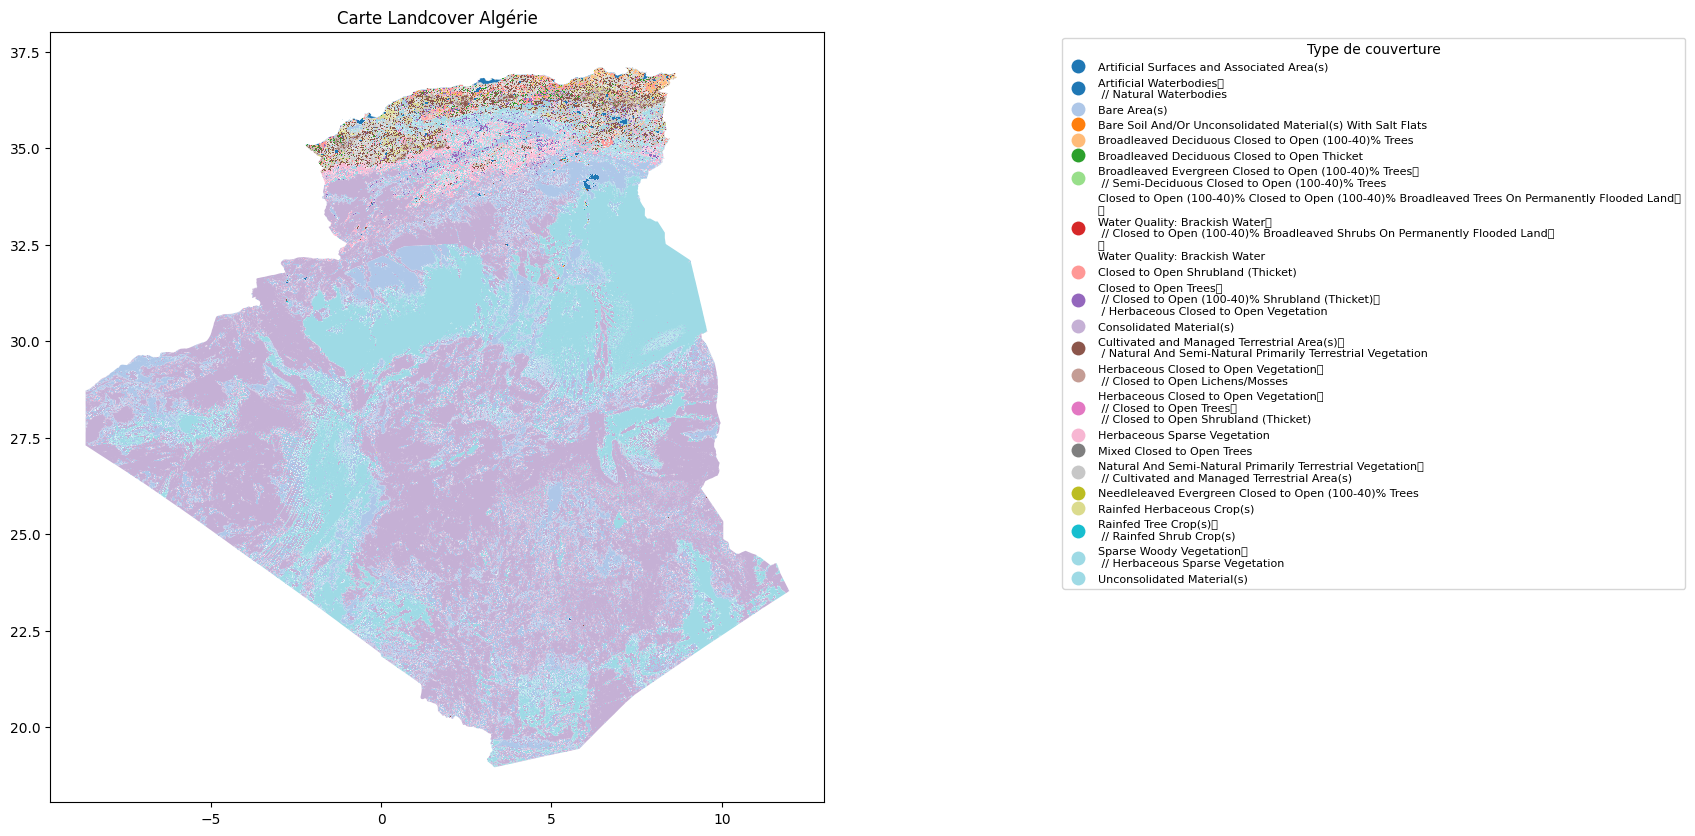

In [4]:
gdfAlg.plot(
    column='LCCLabel',
    cmap='tab20',
    legend=True,
    figsize=(10, 10),
    legend_kwds={
        'bbox_to_anchor': (1.3, 1),   # déplace la légende à droite
        'loc': 'upper left',
        'title': "Type de couverture",
        'fontsize': 8                 # réduit la taille du texte
    }
)
plt.title("Carte Landcover Algérie")
plt.show()

In [5]:
# Charger le fichier Excel contenant les noms de classes
df_classes = pd.read_excel("..\datasets\geonetwork_landcover_tun_gc_adg\globcover_LCCS_legend_africa.xls")

df_classes.head()


,LC,LPos,LCCCode,LCCMode,LCCLevel,LCCOwnLabel,LCCOwnDescr,LCCLabel,MapCode
0,9Mixed Class,1.0,41653-R1 // 41653-R2,0.0,A3A20B2C1D1E2-R1 // A3A20B2C1D1E2-R2,Closedto open broadleavedforest regularly floo...,NaN,Closed to Open Broadleaved Deciduous Woodland ...,160
1,Error,1.0,41739-R1,0.0,A3A20B2C2D1E2-R1,Closed to open broadleaved forest on temporare...,NaN,Closed to Open Broadleaved Deciduous Woodland ...,161
2,0Dichotomous Phase,1.0,0007,0.0,A24,Closed to open grassland or woody vegetation o...,NaN,Natural And Semi-Natural Aquatic or Regularly ...,180
3,9Mixed Class,1.0,41521-R1 // 41521-R2 // 41597-R1 // 41597-R2,0.0,A1A20B1C1-R1 // A1A20B1C1-R2 // A1A20B1C3-R1 /...,Closed to open woody vegetation on regularly f...,NaN,Closed to Open Woody Vegetation On Permanently...,181
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Quality: Fresh Water\r\n // Closed to Open Woo...,NaN


     AREA_M2  ID  GRIDCODE                  LCCCode  \
0  3110936.0   1       210             7001 // 8001   
1   982723.0   3        20              0003 / 0004   
2   151388.0   2        30             0004 // 0003   
3   151391.0   6       120  21454 // 21446 // 21450   
4   151391.0   4        70             21499-121340   

                                            geometry  \
0  POLYGON ((8.89941 37.52083, 8.89923 37.52117, ...   
1  POLYGON ((8.94028 37.52361, 8.94028 37.52917, ...   
2  POLYGON ((8.94583 37.53472, 8.94861 37.53472, ...   
3  POLYGON ((8.91528 37.52917, 8.91528 37.53194, ...   
4  POLYGON ((8.93194 37.53194, 8.9375 37.53194, 8...   

                                            LCCLabel  
0  Artificial Waterbodies\r\n // Natural Waterbodies  
1  Cultivated and Managed Terrestrial Area(s)\r\n...  
2  Natural And Semi-Natural Primarily Terrestrial...  
3  Herbaceous Closed to Open Vegetation\r\n // Cl...  
4  Needleleaved Evergreen Closed to Open (100-40)...  
In

) missing from font(s) DejaVu Sans.thon\Python310\site-packages\geopandas\plotting.py:950: UserWarning: Glyph 13 (
  ax.figure.canvas.draw_idle()
) missing from font(s) DejaVu Sans.thon\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


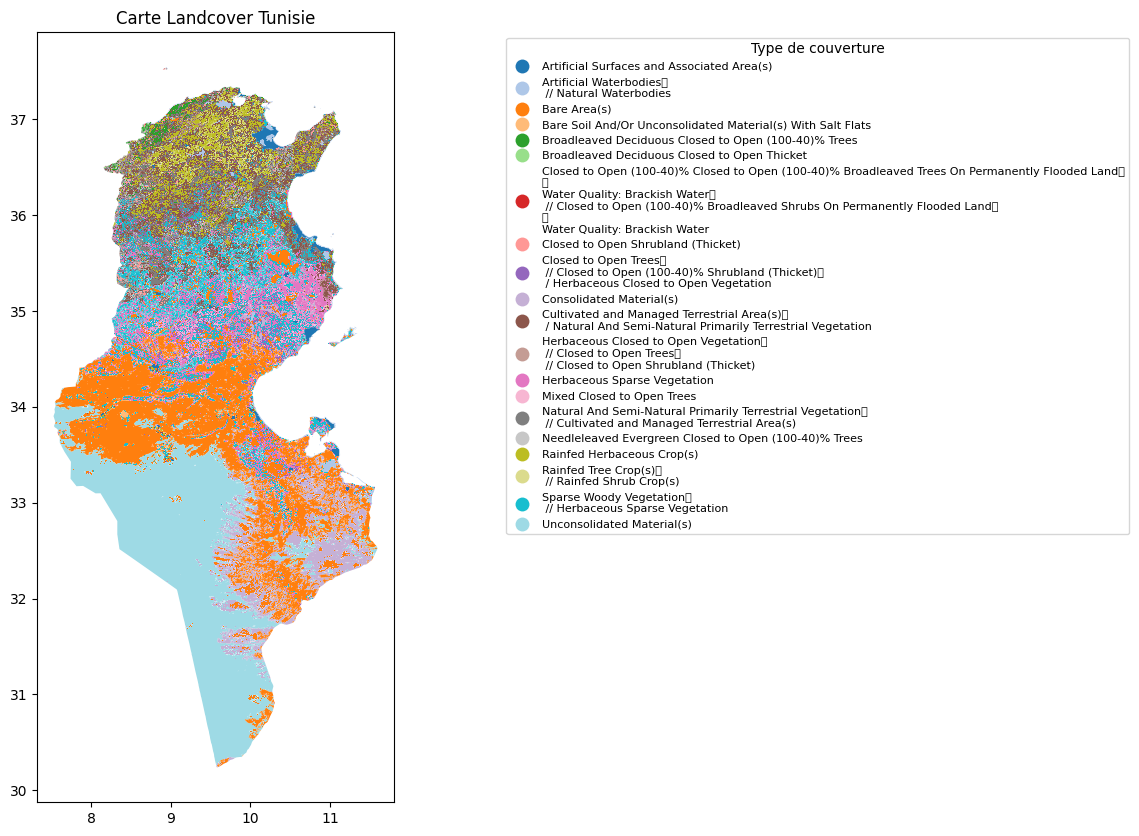

Index([], dtype='object')


In [6]:

# Path to the shapefile
shapefile_path = "../datasets/geonetwork_landcover_tun_gc_adg/tun_gc_adg.shp"

# Load the shapefile
gdfTun = gpd.read_file(shapefile_path)
gdfTun = gdfTun.merge( df_classes[['LCCCode', 'LCCLabel']], left_on='LCCCode', right_on='LCCCode', how='left')


# Display basic info
print(gdfTun.head())
print(gdfTun.columns)


gdfTun.plot(
    column='LCCLabel',
    cmap='tab20',
    legend=True,
    figsize=(10, 10),
    legend_kwds={
        'bbox_to_anchor': (1.3, 1),   # déplace la légende à droite
        'loc': 'upper left',
        'title': "Type de couverture",
        'fontsize': 8                 # réduit la taille du texte
    }
)
plt.title("Carte Landcover Tunisie")
plt.show()

# Harmoniser le nom de colonne avant la fusion
gdfAlg = gdfAlg.rename(columns={'LCCCODE': 'LCCCode'})
gdfTun = gdfTun.rename(columns={'LCCCODE': 'LCCCode'})

print(gdfAlg.columns[gdfAlg.columns.duplicated()])

# Concaténer
gdf_landcover = gpd.GeoDataFrame(pd.concat([gdfAlg, gdfTun], ignore_index=True))



) missing from font(s) DejaVu Sans.thon\Python310\site-packages\geopandas\plotting.py:950: UserWarning: Glyph 13 (
  ax.figure.canvas.draw_idle()
) missing from font(s) DejaVu Sans.thon\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


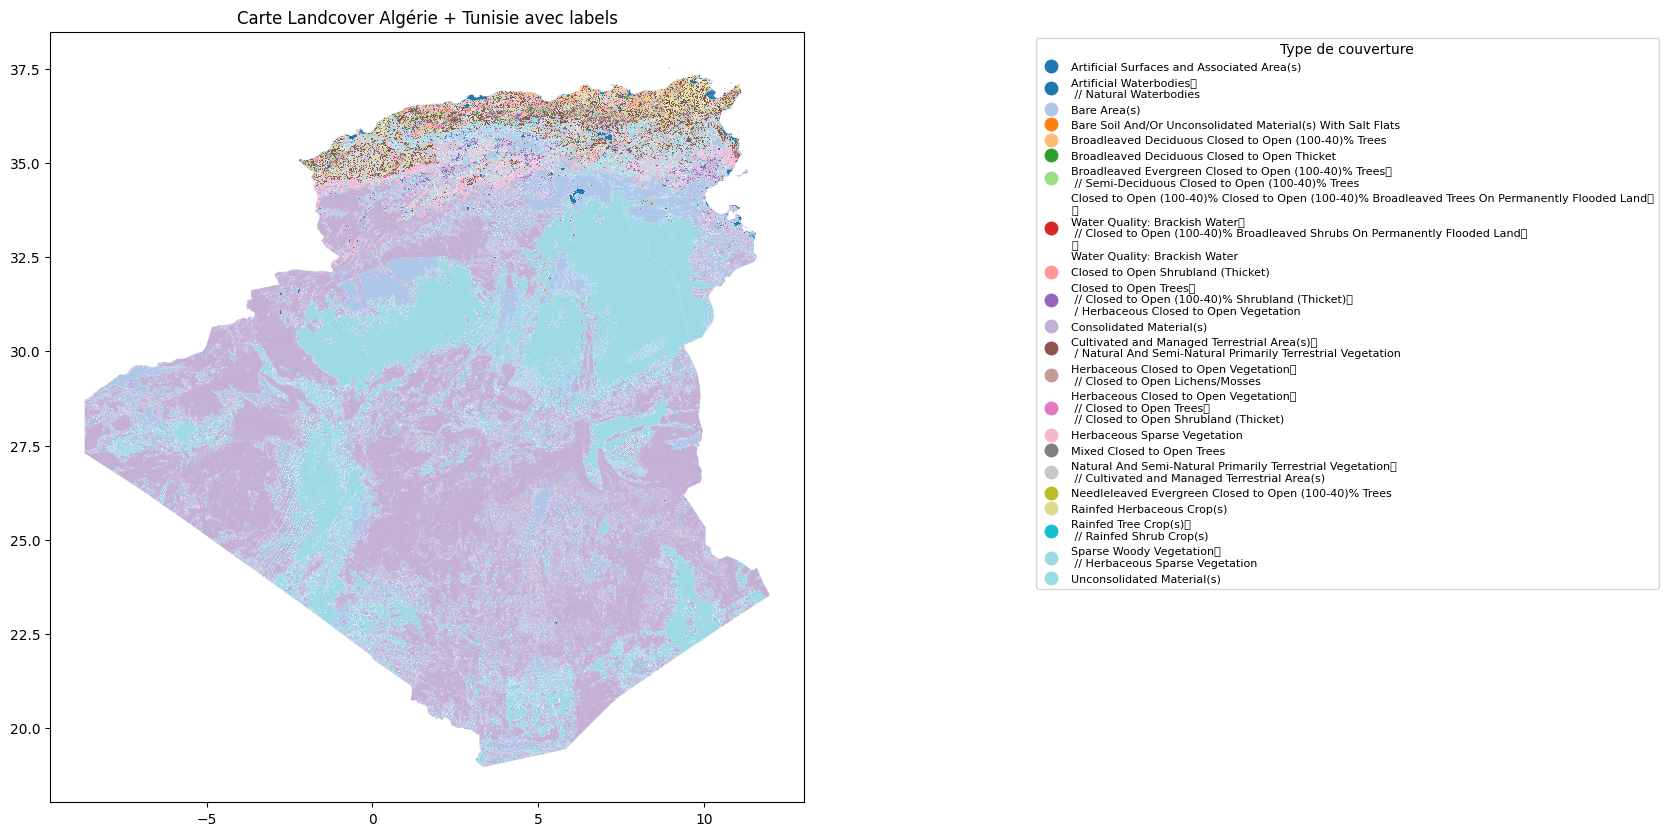

In [7]:
gdf_landcover.plot(
    column='LCCLabel',
    cmap='tab20',
    legend=True,
    figsize=(10, 10),
    legend_kwds={
        'bbox_to_anchor': (1.3, 1),   # déplace la légende à droite
        'loc': 'upper left',
        'title': "Type de couverture",
        'fontsize': 8                 # réduit la taille du texte
    }
)
plt.title("Carte Landcover Algérie + Tunisie avec labels")
plt.show()

## 🔎 Exploratory Data Analysis

In [8]:
print("🔍 INFORMATIONS GÉNÉRALES SUR LE GEODataFrame")
print("="*60)
print(gdf_landcover.info())

print("\n📊 STATISTIQUES DESCRIPTIVES")
print("="*60)
print(gdf_landcover.describe())



print("\n❌ VALEURS MANQUANTES PAR COLONNE")
print("="*60)
print(gdf_landcover.isna().sum())

print("\n👀 APERÇU DES PREMIÈRES LIGNES")
print("="*60)
gdf_landcover.head()

🔍 INFORMATIONS GÉNÉRALES SUR LE GEODataFrame
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 438513 entries, 0 to 438512
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype   
---  ------    --------------   -----   
 0   ID        438513 non-null  int32   
 1   GRIDCODE  438513 non-null  int32   
 2   AREA      386454 non-null  float64 
 3   LCCCode   438513 non-null  object  
 4   geometry  438513 non-null  geometry
 5   LCCLabel  438513 non-null  object  
 6   AREA_M2   52059 non-null   float64 
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 20.1+ MB
None

📊 STATISTIQUES DESCRIPTIVES
                  ID       GRIDCODE          AREA       AREA_M2
count  438513.000000  438513.000000  3.864540e+05  5.205900e+04
mean   173378.294498     156.209934  5.994332e+06  2.981265e+06
std    117981.553876      65.661496  1.267770e+09  2.059695e+08
min         1.000000      14.000000  1.002582e+05  1.002300e+05
25%     57570.000000     150.000000  1

,ID,GRIDCODE,AREA,LCCCode,geometry,LCCLabel,AREA_M2
0,4,210,6.228187e+06,7001 // 8001,"POLYGON ((6.41528 37.08696, 6.43103 37.0855, 6...",Artificial Waterbodies\r\n // Natural Waterbodies,NaN
1,2,210,6.242408e+06,7001 // 8001,"POLYGON ((7.18084 37.07917, 7.17998 37.08091, ...",Artificial Waterbodies\r\n // Natural Waterbodies,NaN
2,1,210,1.482995e+06,7001 // 8001,"POLYGON ((7.37137 37.08194, 7.3709 37.08717, 7...",Artificial Waterbodies\r\n // Natural Waterbodies,NaN
3,8,50,4.590841e+08,21497-121340,"POLYGON ((6.12361 36.68472, 6.12361 36.69306, ...",Broadleaved Deciduous Closed to Open (100-40)%...,NaN
4,13,210,6.371533e+06,7001 // 8001,"POLYGON ((6.26181 37.02361, 6.26193 37.02514, ...",Artificial Waterbodies\r\n // Natural Waterbodies,NaN


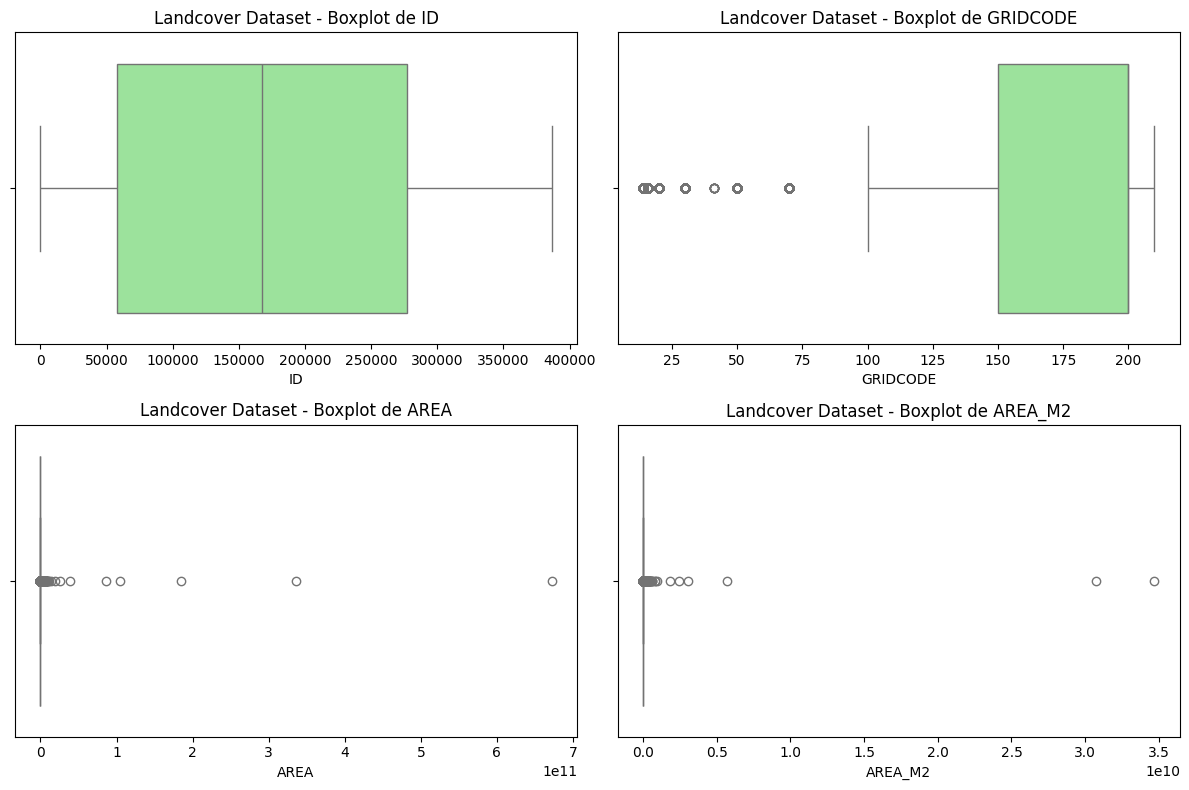

In [9]:
plot_boxplots(gdf_landcover, title_prefix="Landcover Dataset - Boxplot de", color='lightgreen')

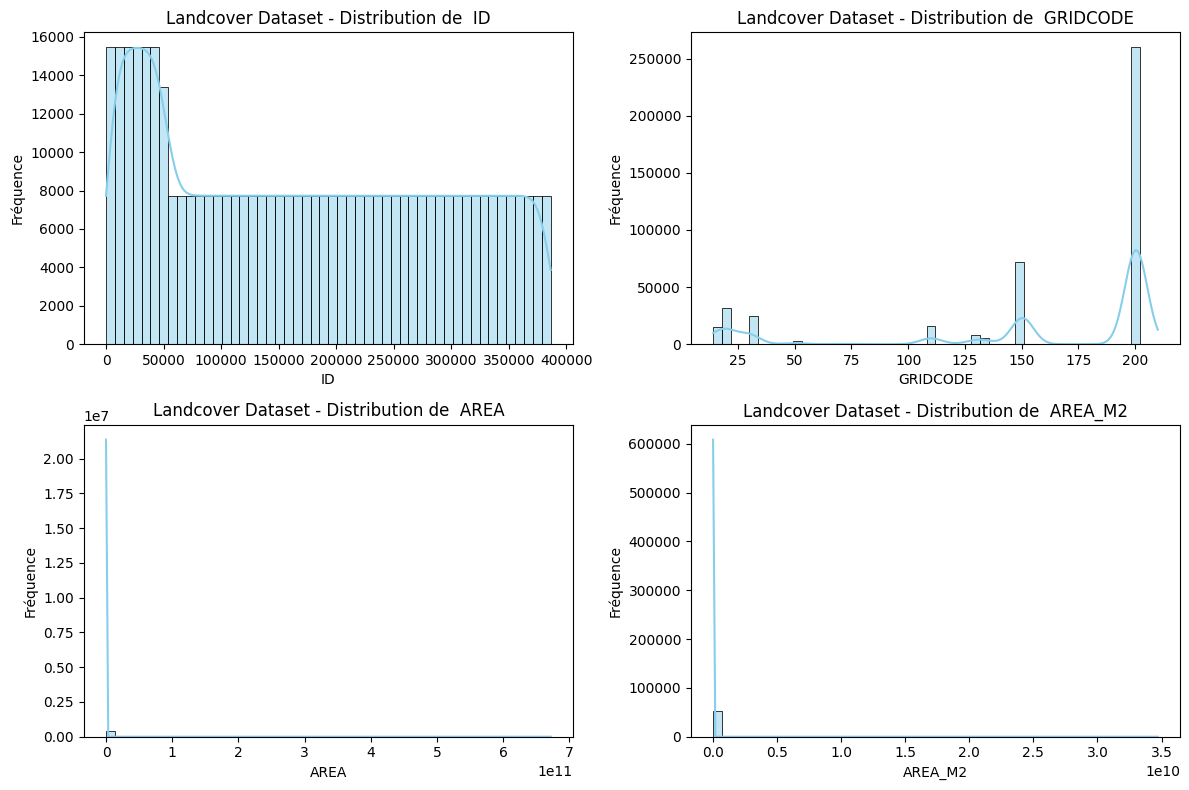

In [10]:
plot_distributions(gdf_landcover, title_prefix="Landcover Dataset - Distribution de ", color='skyblue')

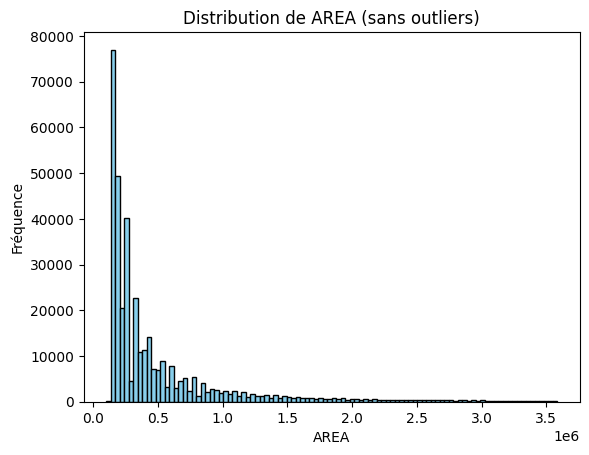

In [11]:

subset = gdf_landcover[gdf_landcover['AREA'] < gdf_landcover['AREA'].quantile(0.95)]  # garder 95% des plus petites valeurs
plt.hist(subset['AREA'], bins=100, color='skyblue', edgecolor='k')
plt.xlabel('AREA')
plt.ylabel('Fréquence')
plt.title('Distribution de AREA (sans outliers)')
plt.show()


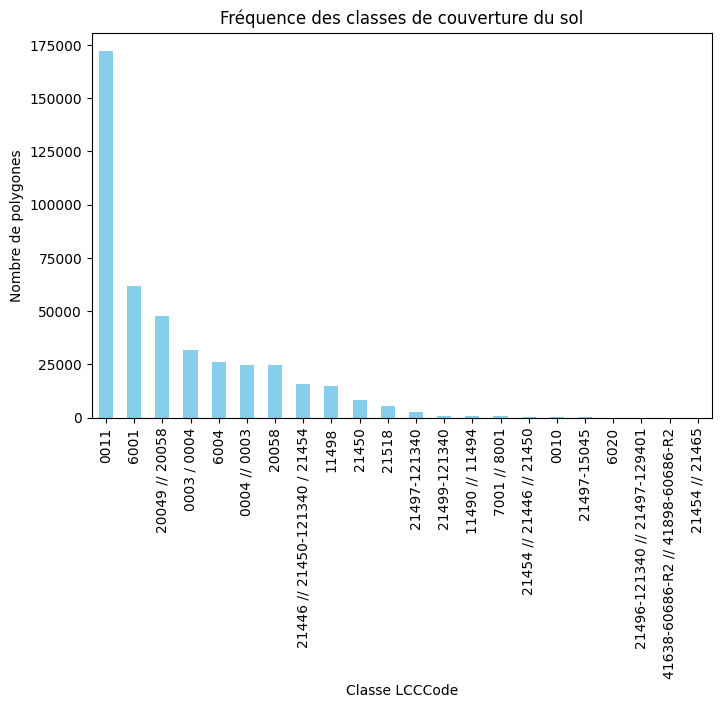

In [12]:
gdf_landcover['LCCCode'].value_counts().plot(
    kind='bar',
    figsize=(8,5),
    color='skyblue'
)
plt.title("Fréquence des classes de couverture du sol")
plt.xlabel("Classe LCCCode")
plt.ylabel("Nombre de polygones")
plt.show()


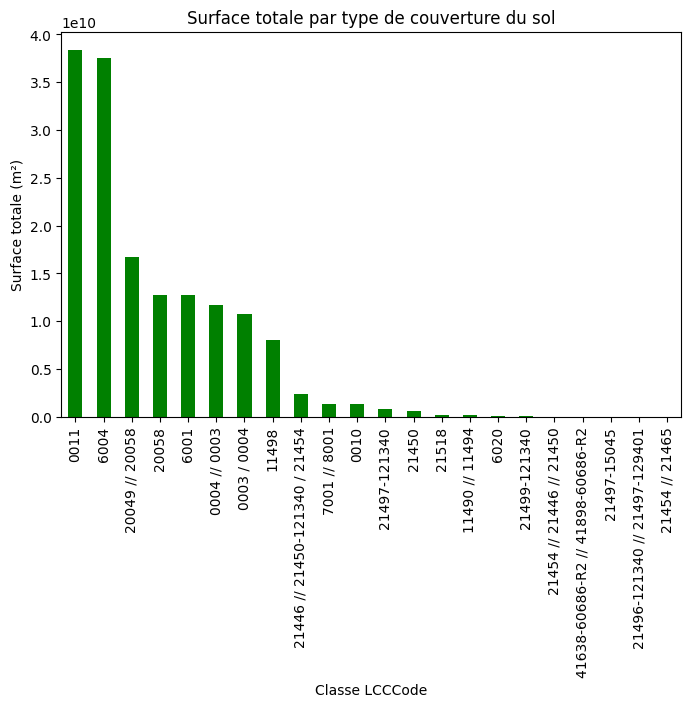

In [13]:
area_by_class = gdf_landcover.groupby('LCCCode')['AREA_M2'].sum().sort_values(ascending=False)

area_by_class.plot(kind='bar', figsize=(8,5), color='green')
plt.title("Surface totale par type de couverture du sol")
plt.xlabel("Classe LCCCode")
plt.ylabel("Surface totale (m²)")
plt.show()

## 🧼 Data Cleaning and Pre-processing

### Deleting useless columns

In [14]:
gdf_landcover_cleaned = gdf_landcover.drop(columns=['LCCLabel', 'ID', 'AREA', 'AREA_M2','LCCCode'])
gdf_landcover_cleaned.head()

,GRIDCODE,geometry
0,210,"POLYGON ((6.41528 37.08696, 6.43103 37.0855, 6..."
1,210,"POLYGON ((7.18084 37.07917, 7.17998 37.08091, ..."
2,210,"POLYGON ((7.37137 37.08194, 7.3709 37.08717, 7..."
3,50,"POLYGON ((6.12361 36.68472, 6.12361 36.69306, ..."
4,210,"POLYGON ((6.26181 37.02361, 6.26193 37.02514, ..."


In [15]:
output_landcover_path = '../cleaned_datasets/cleaned_landcover_data.gpkg'
gdf_landcover_cleaned.to_file(output_landcover_path, driver='GPKG')
print(f"gdf_landcover_cleaned sauvegardé en {output_landcover_path}")

gdf_landcover_cleaned sauvegardé en ../cleaned_datasets/cleaned_landcover_data.gpkg
